In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
from torchvision import datasets

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),# sacale
    transforms.Normalize((0.5,), (0.5,)) # [-1,1]
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [3]:
from torch.utils.data import DataLoader
trainloader=DataLoader(train_dataset,batch_size=64,shuffle=True)
testloader=DataLoader(test_dataset,batch_size=64)

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.convo_layer=nn.Sequential(
            nn.Conv2d(1,32,padding=1,kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32,64,padding=1,kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64,128,padding=1,kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.fuly_layer=nn.Sequential(
            nn.Linear(3*3*128,256),#7/2=3
            nn.ReLU(),

            nn.Linear(256,10),
            
        ) 
    def forward(self,x):
        x=self.convo_layer(x)
        x=torch.flatten(x,start_dim=1)
        x=self.fuly_layer(x)
        return x

In [5]:
model=CNN()
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters())

In [6]:
epochs = 10

for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()
        
        output = model.forward(images) # FP
        loss = criterion(output, labels) # loss fnx
        loss.backward() # BP
        optimizer.step() # update params

        epoch_training_loss += loss.item()

    print(f"epoch={epoch+1}/{epochs} & loss={epoch_training_loss/len(trainloader)}")

epoch=1/10 & loss=0.14891480727951284
epoch=2/10 & loss=0.04140880143351561
epoch=3/10 & loss=0.02954149244583772
epoch=4/10 & loss=0.02311088223642286
epoch=5/10 & loss=0.01848977899237598
epoch=6/10 & loss=0.015323328360018752
epoch=7/10 & loss=0.012669718266090198
epoch=8/10 & loss=0.011074343596850559
epoch=9/10 & loss=0.009665987439275743
epoch=10/10 & loss=0.008910708847135768


In [7]:
model.eval()
correct=0
total=0
with torch.no_grad():
    for xb,yb in testloader:
        output=model.forward(xb)
        _,pred=torch.max(output,1)
        correct+=(pred==yb).sum().item()
        total+=yb.size(0)
print(f"accuracy = {correct / total * 100}")        

accuracy = 99.11999999999999


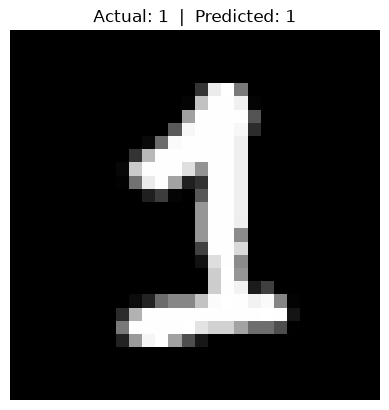

In [16]:
import matplotlib.pyplot as plt
import random
import torch

# 1. Model ko evaluation mode mein set karna (taaki dropout waghera disable ho jaye)
model.eval()

# 2. Test dataset mein se ek random index chunna
random_idx = random.randint(0, len(test_dataset) - 1)

# 3. Us index se image aur uska actual label nikalna
image, actual_label = test_dataset[random_idx]

# 4. PyTorch model ko batch format chahiye hota hai, toh ek dummy batch dimension add karein
# shape (1, 28, 28) se (1, 1, 28, 28) ho jayega
image_input = image.unsqueeze(0)

# 5. Model se prediction nikalna bina gradients calculate kiye (memory bachane ke liye)
with torch.no_grad():
    output = model(image_input)
    # output mein sabse high probability wale class ka index nikalna
    _, predicted_label = torch.max(output, 1)

# 6. Image ko tensor se numpy array mein convert karna display ke liye
# (1, 28, 28) shape ko (28, 28) mein badalna
image_for_display = image.squeeze().numpy()

# 7. Image aur labels ko plot karna
plt.imshow(image_for_display, cmap='gray')
plt.title(f"Actual: {actual_label}  |  Predicted: {predicted_label.item()}")
plt.axis('off') # Axes chupane ke liye
plt.show()